# Data Preprocessing

In [4]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wholesale_customers = fetch_ucirepo(id=292)

# data (as pandas dataframes)
X = wholesale_customers.data.features
y = wholesale_customers.data.targets

# metadata
print(wholesale_customers.metadata)

# variable information
print(wholesale_customers.variables)


{'uci_id': 292, 'name': 'Wholesale customers', 'repository_url': 'https://archive.ics.uci.edu/dataset/292/wholesale+customers', 'data_url': 'https://archive.ics.uci.edu/static/public/292/data.csv', 'abstract': 'The data set refers to clients of a wholesale distributor. It includes the annual spending in monetary units (m.u.) on diverse product categories', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 440, 'num_features': 7, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Region'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2013, 'last_updated': 'Mon Feb 05 2024', 'dataset_doi': '10.24432/C5030X', 'creators': ['Margarida Cardoso'], 'intro_paper': None, 'additional_info': {'summary': None, 'purpose': None, 'funded_by': None, 'instances_represent': None, 'recommended_data_splits': None, 'sensitive_data': None, 'preprocessing_description':

In [6]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


In [7]:
#building data frame
df = pd.concat([y, X], axis=1)

spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

print(f"Shape: {df.shape}")
df.head()

Shape: (440, 8)


,Region,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,3,2,12669,9656,7561,214,2674,1338
1,3,2,7057,9810,9568,1762,3293,1776
2,3,2,6353,8808,7684,2405,3516,7844
3,3,1,13265,1196,4221,6404,507,1788
4,3,2,22615,5410,7198,3915,1777,5185


In [8]:
#inspecting structure
print("="*55)
print(f"  Samples : {df.shape[0]}")
print(f"  Features: {df.shape[1]}")
print("="*55)

print("\n Data Types")
print(df.dtypes)

print("\n Stat")
display(df.describe())

  Samples : 440
  Features: 8

 Data Types
Region              int64
Channel             int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

 Stat


,Region,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,2.543182,1.322727,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.774272,0.468052,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,2.000000,1.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,3.000000,1.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,3.000000,2.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,3.000000,2.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [9]:
#check for any missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)

if missing.sum() == 0:
    print("\n no missing values ")
else:
    print("\n missing values , add median instead ")
    df.fillna(df.median(numeric_only=True), inplace=True)

Missing values per column:
Region              0
Channel             0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

 no missing values 


In [10]:
# checking for duplicates and removing them
n_before = len(df)
df.drop_duplicates(inplace=True)
n_after = len(df)

print(f"Rows before       : {n_before}")
print(f"Rows after        : {n_after}")
print(f"Duplicates removed: {n_before - n_after}")


Rows before       : 440
Rows after        : 440
Duplicates removed: 0


In [11]:
# resplit el x wel y after el concat el kan fel awl
df.reset_index(drop=True, inplace=True)
X = df[spending_cols].copy()
y = df[['Channel', 'Region']].copy()

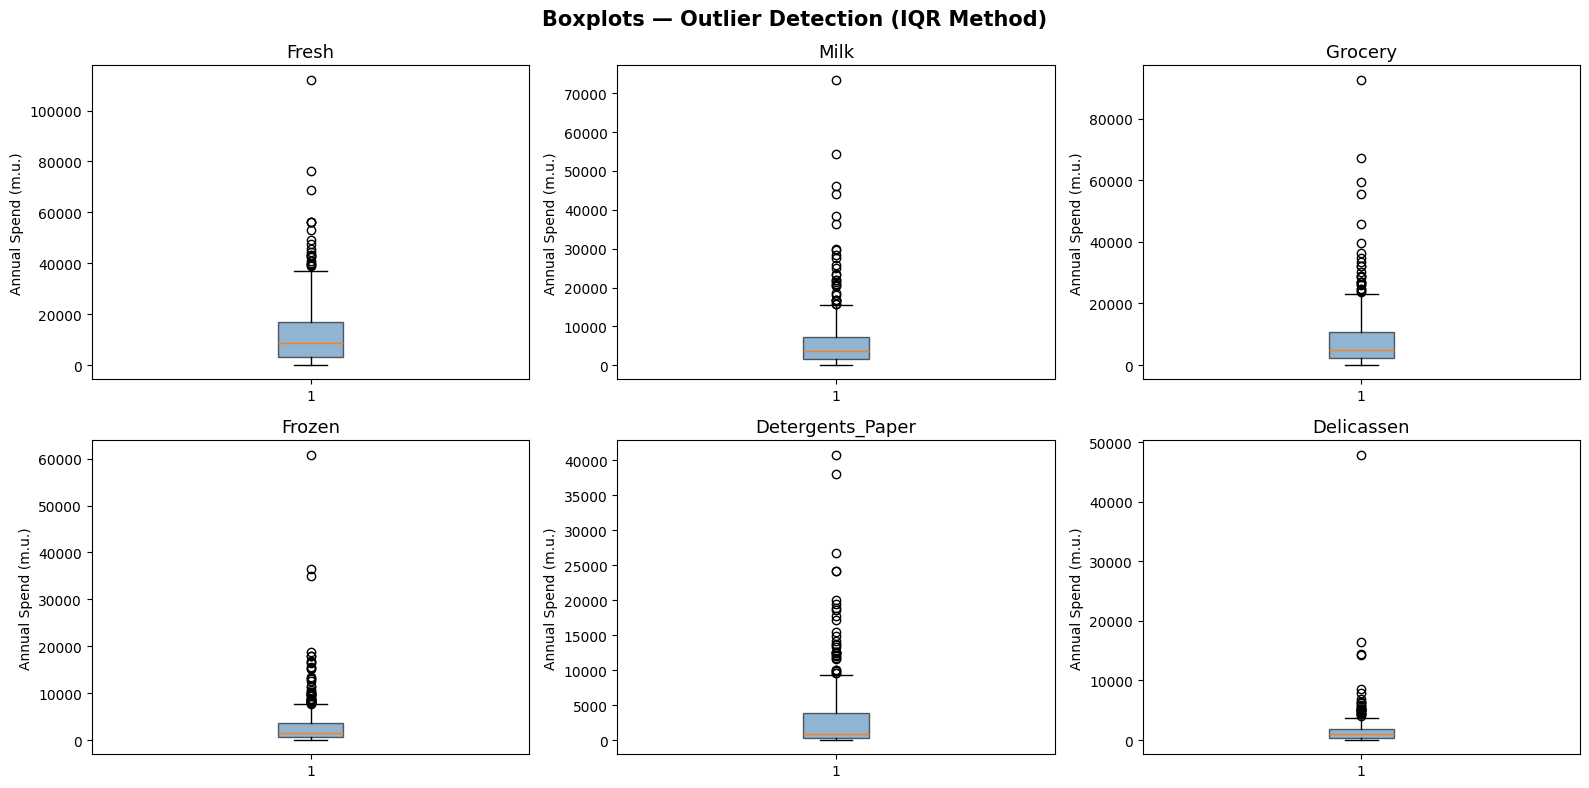

In [12]:
# checking for outliers before normalization
#1- boxplot
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(spending_cols):
    axes[i].boxplot(X[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=13)
    axes[i].set_ylabel('Annual Spend (m.u.)')

plt.suptitle('Boxplots — Outlier Detection (IQR Method)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
#2- z score
print("\n Z-Score outlier count (|z| > 3) per feature")
z_scores = np.abs(stats.zscore(X))
outlier_counts = (z_scores > 3).sum()
print(outlier_counts)


 Z-Score outlier count (|z| > 3) per feature
43


outliers are detected but they represent high volume customers so we will not remove them  however standardization will reduce their influence

we will use standardization and not min max because all features are right skewed and min max hykhaly values (0,1)  , standard scaler will be better and robust

In [14]:
#standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=spending_cols)

print(f"\nMean per feature (should be 0):\n{X_scaled_df.mean().round(6)}")
print(f"\nStd  per feature (should be 1):\n{X_scaled_df.std().round(6)}")


Mean per feature (should be 0):
Fresh              -0.0
Milk                0.0
Grocery            -0.0
Frozen              0.0
Detergents_Paper    0.0
Delicassen         -0.0
dtype: float64

Std  per feature (should be 1):
Fresh               1.001138
Milk                1.001138
Grocery             1.001138
Frozen              1.001138
Detergents_Paper    1.001138
Delicassen          1.001138
dtype: float64


we don't need pca as we already have 6 features only , we don't need dimensionality reduction  , this will affect the clustering process however we can use it for visualization only

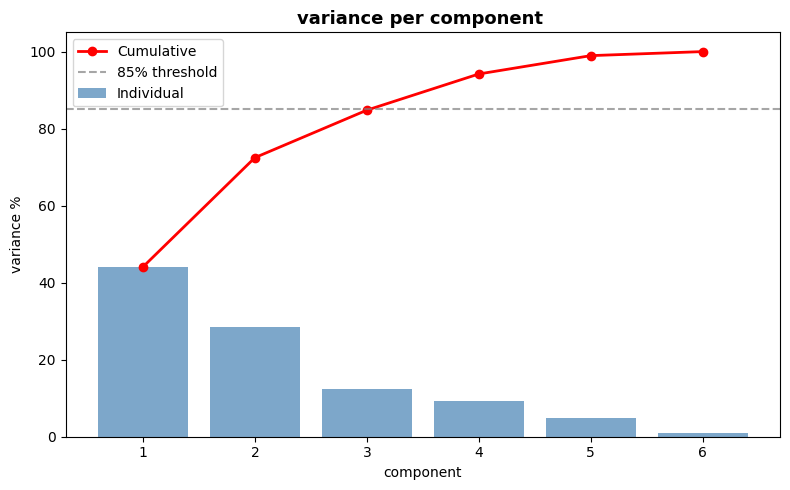


  Variance per Component 
PC1: 44.08%  |  Cumulative: 44.08%
PC2: 28.38%  |  Cumulative: 72.46%
PC3: 12.33%  |  Cumulative: 84.79%
PC4: 9.40%  |  Cumulative: 94.19%
PC5: 4.76%  |  Cumulative: 98.95%
PC6: 1.05%  |  Cumulative: 100.00%
Variance captured by PC1 + PC2: 72.46%


In [15]:
#PCA FOR VISUALIZATION WITHOUT REDUCTION
pca_full = PCA()
pca_full.fit(X_scaled)

explained  = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Plot explained variance
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(1, 7), explained * 100, color='steelblue', alpha=0.7, label='Individual')
ax.plot(range(1, 7), cumulative * 100, 'ro-', linewidth=2, label='Cumulative')
ax.axhline(85, color='gray', linestyle='--', alpha=0.7, label='85% threshold')
ax.set_xlabel('component')
ax.set_ylabel('variance %')
ax.set_title('variance per component ', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\n  Variance per Component ")
for i, (ind, cum) in enumerate(zip(explained, cumulative)):
    print(f"PC{i+1}: {ind*100:.2f}%  |  Cumulative: {cum*100:.2f}%")

# Fit 2D PCA — used in visualization cells
pca_2d = PCA(n_components=2)
X_pca2 = pca_2d.fit_transform(X_scaled)
print(f"Variance captured by PC1 + PC2: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")


# Data visualization

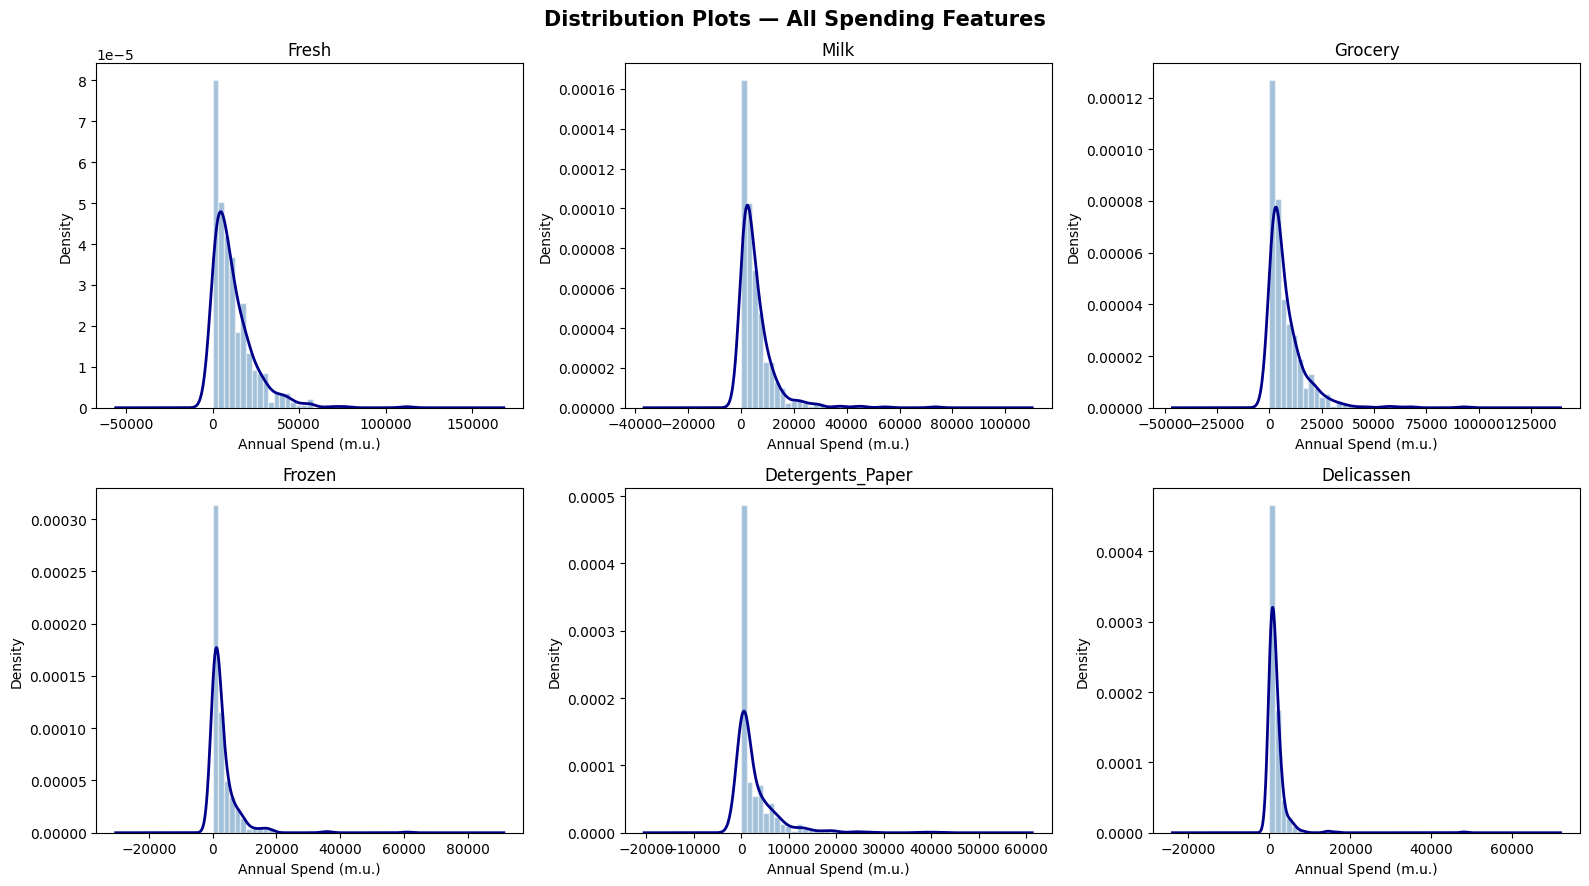

In [16]:
#• Distribution plots for numerical features
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(spending_cols):
    axes[i].hist(X[col], bins=35, color='steelblue', alpha=0.5,
                 density=True, edgecolor='white')
    X[col].plot.kde(ax=axes[i], color='darkblue', linewidth=2)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Annual Spend (m.u.)')
    axes[i].set_ylabel('Density')

plt.suptitle('Distribution Plots — All Spending Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

interpretation : all features are right skewed

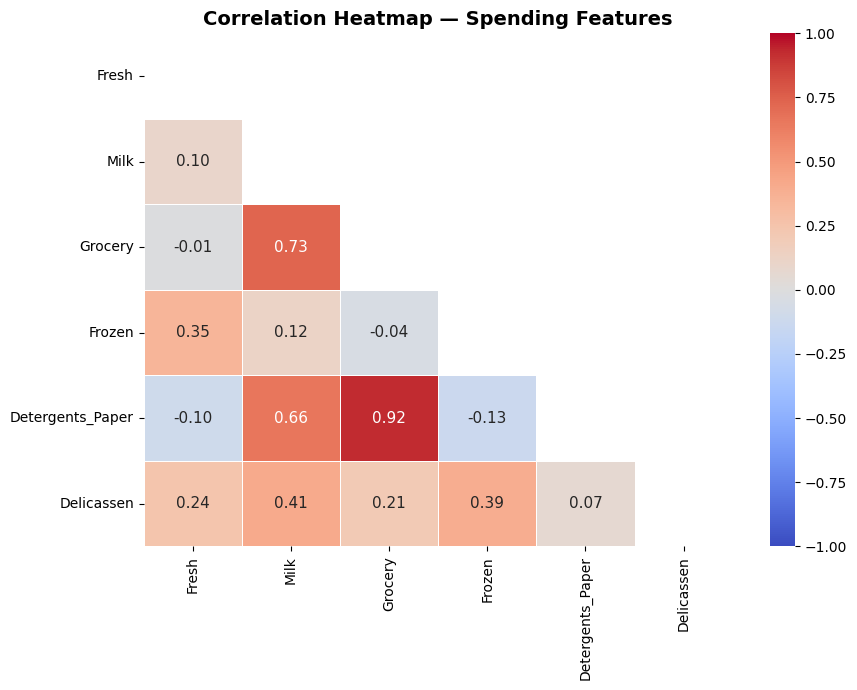

In [17]:
#• Correlation heatmap to analyze relationships between variables
corr = X.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size": 11})
ax.set_title('Correlation Heatmap — Spending Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

interpretation : grocery and detergent are positively correlated  , also milk has moderate correlation to them  while fresh and frozen are independent of others

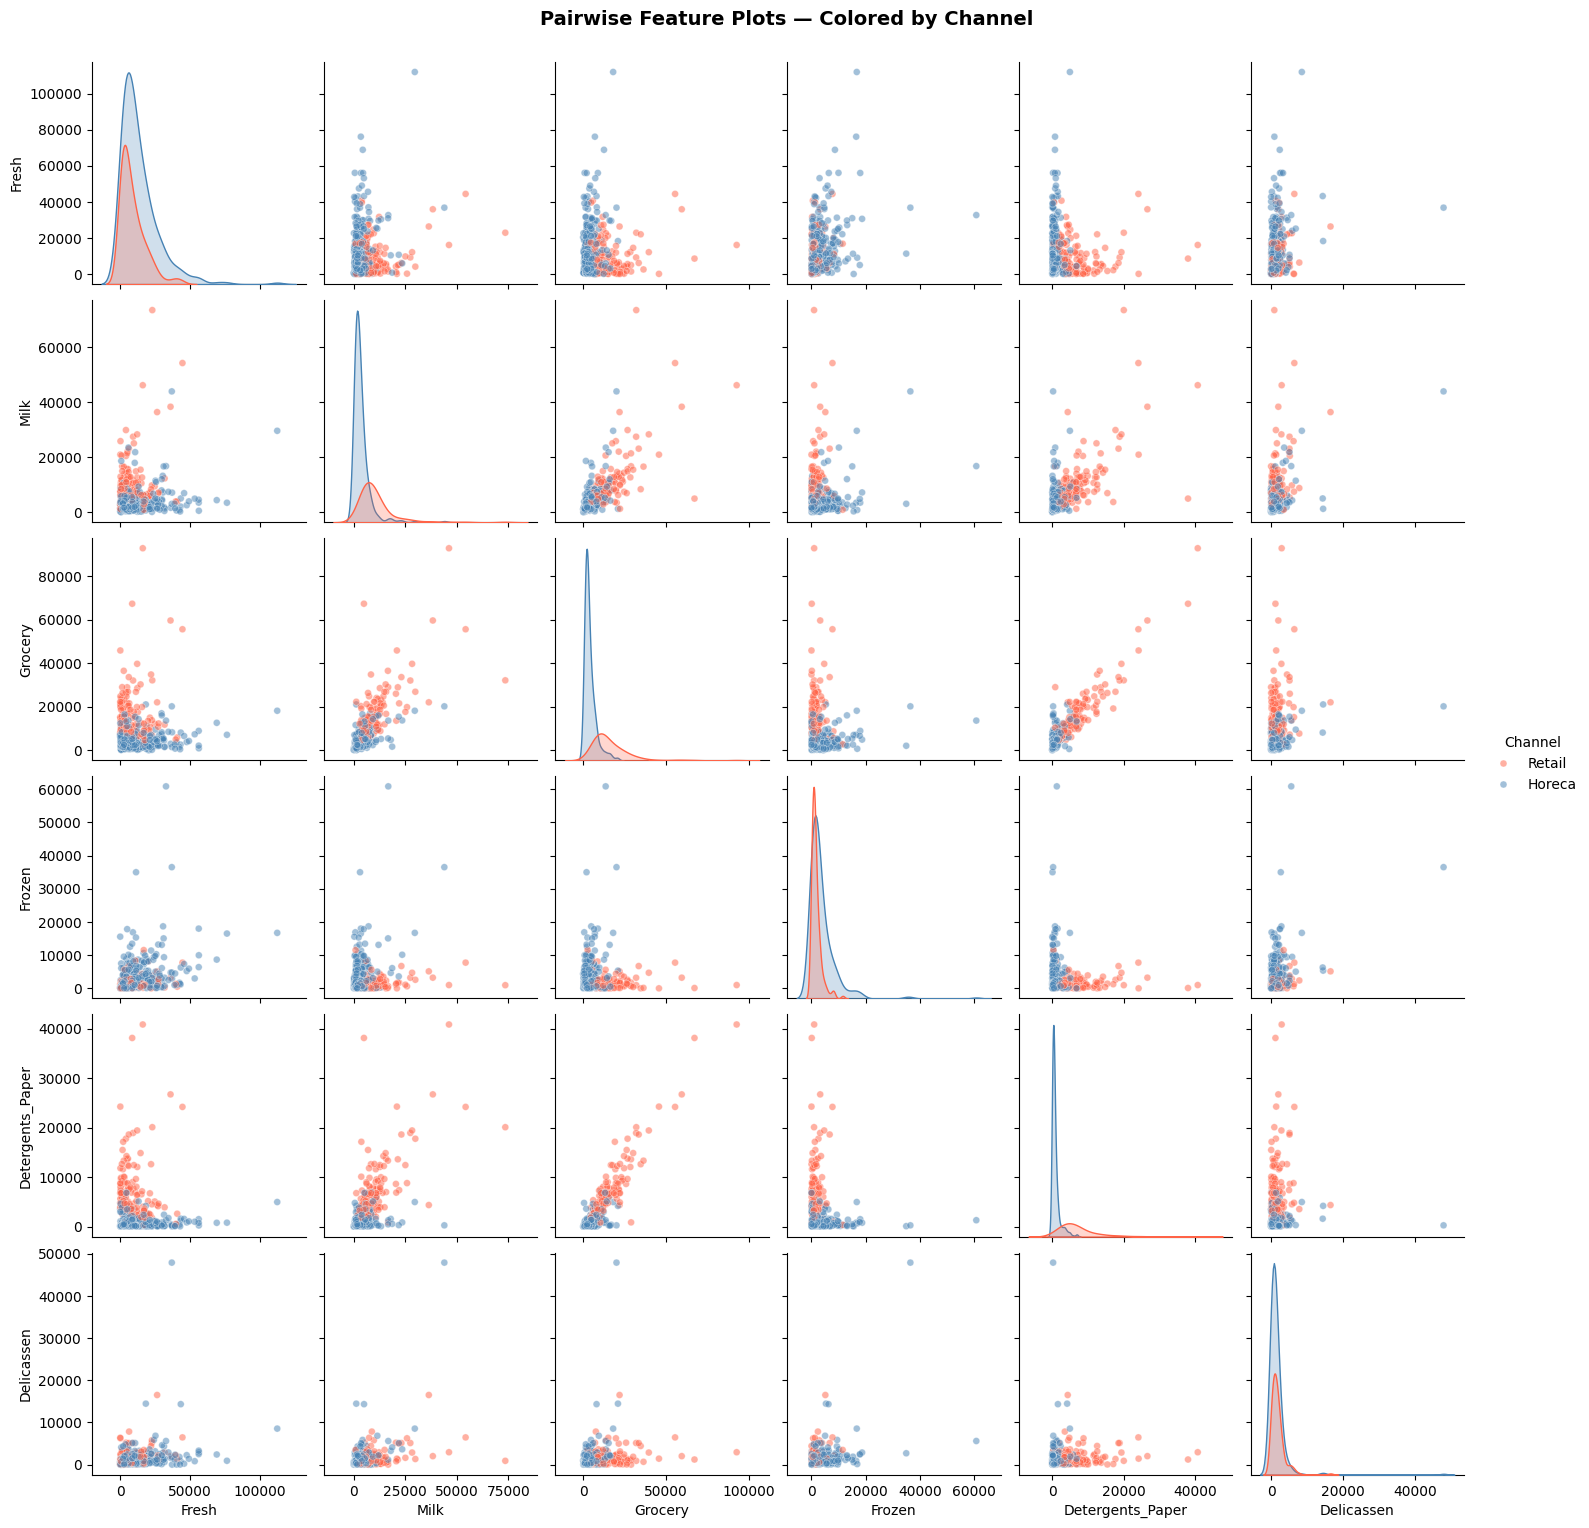

In [18]:
#• Pairwise feature plots to observe feature interactions.
pair_df = X.copy()
pair_df['Channel'] = y['Channel'].map({1: 'Horeca', 2: 'Retail'}).values

g = sns.pairplot(pair_df, hue='Channel', diag_kind='kde',
                 plot_kws=dict(alpha=0.5, s=25),
                 palette={'Horeca': 'steelblue', 'Retail': 'tomato'})
g.fig.suptitle('Pairwise Feature Plots — Colored by Channel',
               y=1.02, fontsize=14, fontweight='bold')
plt.show()

interpretation :grocery vs detergents pair shows the clearest
separation between Horeca and Retail channels

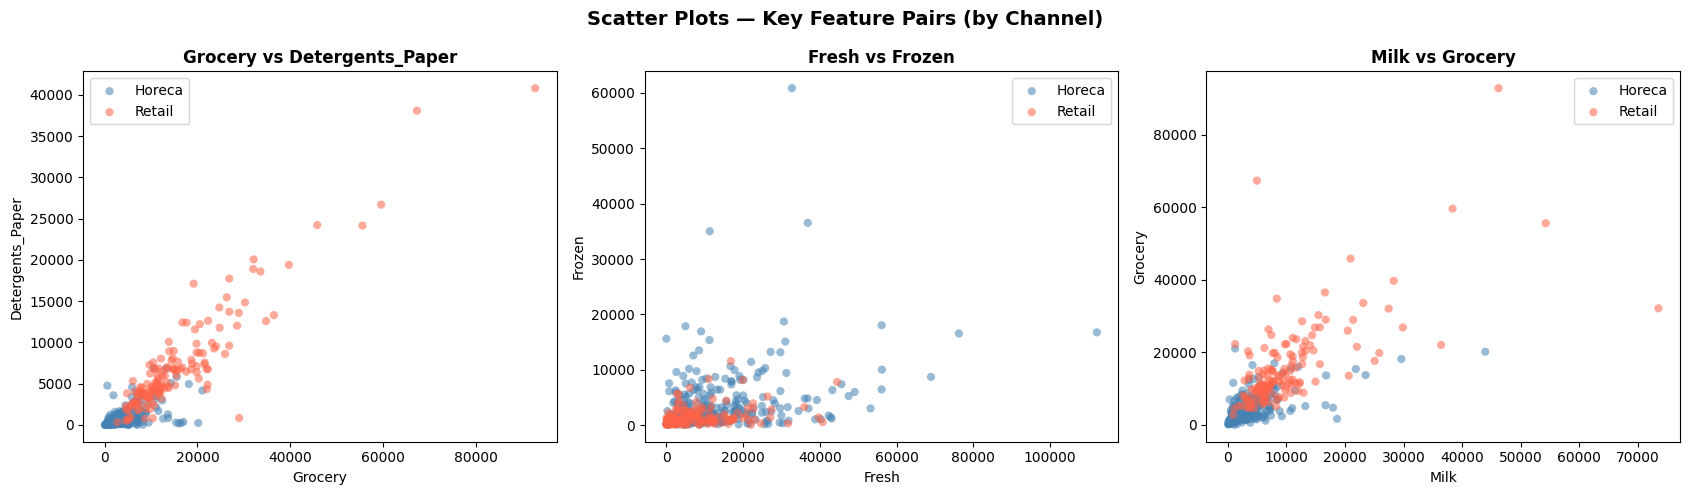

In [19]:
#• Scatter plots between selected feature pairs.
key_pairs = [
    ('Grocery', 'Detergents_Paper'),
    ('Fresh',   'Frozen'),
    ('Milk',    'Grocery'),
]

palette = {'Horeca': 'steelblue', 'Retail': 'tomato'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (fx, fy) in zip(axes, key_pairs):
    for ch, label in [(1, 'Horeca'), (2, 'Retail')]:
        mask = (y['Channel'] == ch).values
        ax.scatter(X.loc[mask, fx], X.loc[mask, fy],
                   c=palette[label], label=label,
                   alpha=0.55, s=35, edgecolors='none')
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)
    ax.set_title(f'{fx} vs {fy}', fontsize=12, fontweight='bold')
    ax.legend()

plt.suptitle('Scatter Plots — Key Feature Pairs (by Channel)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


interpratation :  

1- Grocery vs Detergents: clearest separation (Retail customers) , cluster is in upper right : high spendings on both

2-Fresh vs Frozen: both channels overlap more, but horeca customers
tend to spend more on Fresh produce.

3-Milk vs Grocery: moderate separation — Retail customers again skew : spendings are higher in both


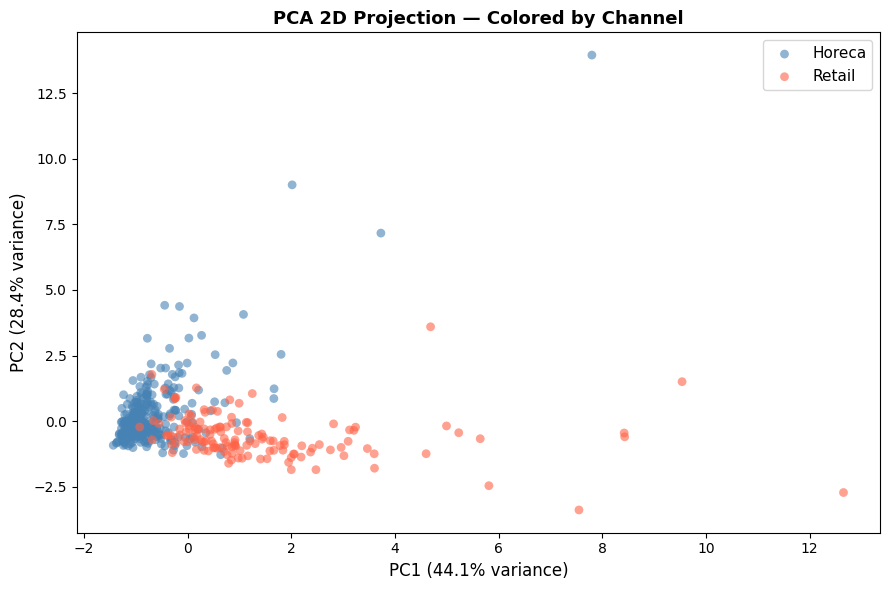

In [20]:
#• Two-dimensional visualization using PCA projection
palette = {'Horeca': 'steelblue', 'Retail': 'tomato'}

fig, ax = plt.subplots(figsize=(9, 6))
for ch, label in [(1, 'Horeca'), (2, 'Retail')]:
    mask = y['Channel'].values == ch
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               c=palette[label], label=label,
               alpha=0.6, s=40, edgecolors='none')

var1, var2 = pca_2d.explained_variance_ratio_ * 100
ax.set_xlabel(f'PC1 ({var1:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({var2:.1f}% variance)', fontsize=12)
ax.set_title('PCA 2D Projection — Colored by Channel',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

interpretation :  imperfect separation between Horeca and Retail customers, with some
overlap in the middle , in data they maybe not perfectly linearly separable

In [21]:
#• Apply t-SNE to obtain a non-linear two-dimensional visualization of the dataset.
#If it’s not necessary to use any of the above, write your explanation.

#tsne = TSNE(n_components=2, perplexity=30, random_state=42,
        #    learning_rate='auto', init='pca', n_iter=1000)
#X_tsne = tsne.fit_transform(X_scaled)

#palette = {'Horeca': 'steelblue', 'Retail': 'tomato'}

#fig, ax = plt.subplots(figsize=(9, 6))
#for ch, label in [(1, 'Horeca'), (2, 'Retail')]:
 #   mask = y['Channel'].values == ch
  #  ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
             #  c=palette[label], label=label,
              # alpha=0.6, s=40, edgecolors='none')

#ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
#ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
#ax.set_title('t-SNE 2D Visualization — Colored by Channel',
     #        fontsize=13, fontweight='bold')
#ax.legend(fontsize=11)
#plt.tight_layout()
#plt.show()

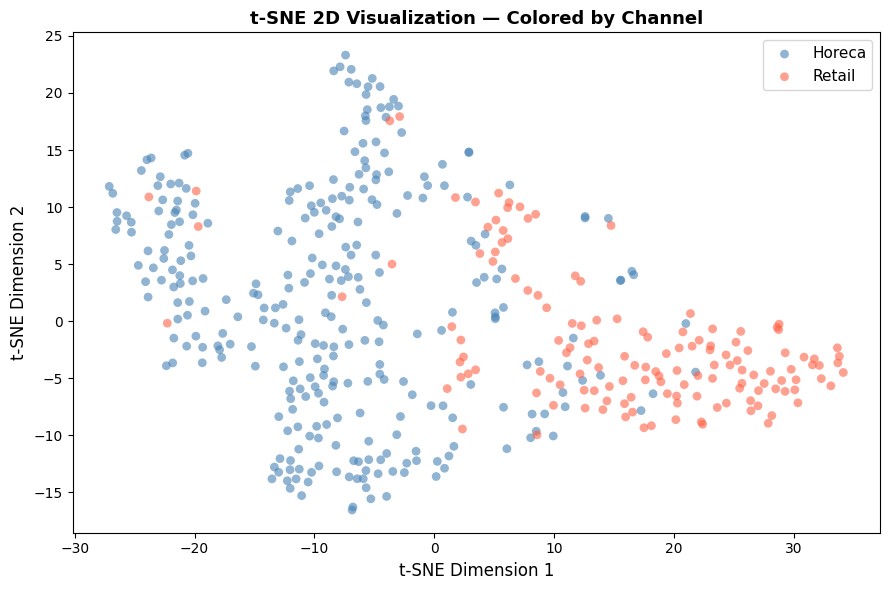

In [22]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Apply t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    learning_rate='auto',
    init='pca',
    max_iter=1000   # ✅ fixed (was n_iter)
)

X_tsne = tsne.fit_transform(X_scaled)

# Plot
palette = {'Horeca': 'steelblue', 'Retail': 'tomato'}

fig, ax = plt.subplots(figsize=(9, 6))

for ch, label in [(1, 'Horeca'), (2, 'Retail')]:
    mask = y['Channel'].values == ch
    ax.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=palette[label],
        label=label,
        alpha=0.6,
        s=40,
        edgecolors='none'
    )

ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax.set_title('t-SNE 2D Visualization — Colored by Channel',
             fontsize=13, fontweight='bold')

ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

why did we use t-SNE?
because PCA is a linear method and our data is not linearly separable data so PCA will not reveal cluster structure however t-SNE maps high dimnsional data

interpretation : we have more compact separation between horeca and retail customers , also sub clusters are visible which means that all clustering techniques requested in the milestone EXCEPT FOR ELBOW may find more than 2 groups in data

In [23]:
# data prep for clustering after scaling
df_export = X_scaled_df.copy()
df_export['Channel'] = y['Channel'].values
df_export['Region']  = y['Region'].values

df_export.to_csv('wholesale_scaled.csv', index=False)

print(" wholesale_scaled.csv saved.")
print(f"   Shape: {df_export.shape}")
print("""
Variables ready for the clustering team:
  X_scaled     → numpy array (440, 6) — feed directly to K-Means, GMM, Spectral
  X_scaled_df  → same as DataFrame
  X_pca2       → numpy array (440, 2) — for 2D cluster visualization
  X_tsne       → numpy array (440, 2) — for 2D cluster visualization
  y['Channel'] → ground-truth labels  — for post-clustering evaluation only
""")

 wholesale_scaled.csv saved.
   Shape: (440, 8)

Variables ready for the clustering team:
  X_scaled     → numpy array (440, 6) — feed directly to K-Means, GMM, Spectral
  X_scaled_df  → same as DataFrame
  X_pca2       → numpy array (440, 2) — for 2D cluster visualization
  X_tsne       → numpy array (440, 2) — for 2D cluster visualization
  y['Channel'] → ground-truth labels  — for post-clustering evaluation only



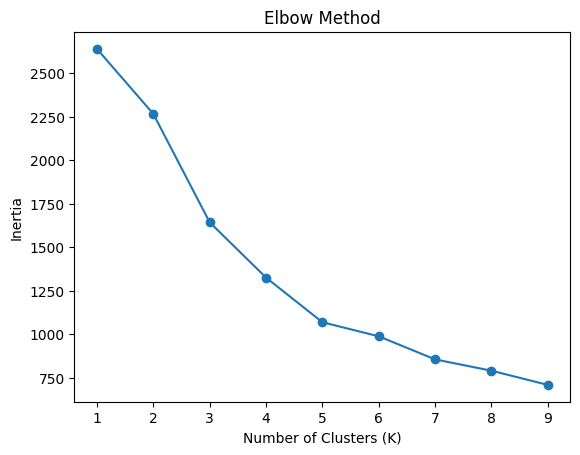

In [24]:
# Step 1: Apply Elbow Method to find optimal number of clusters

from sklearn.cluster import KMeans        # Import KMeans clustering algorithm
import matplotlib.pyplot as plt           # Import plotting library

inertia = []                              # Create an empty list to store inertia values

K_range = range(1, 10)                    # Define range of K values (from 1 to 9)

# Loop through different values of K
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)  # Create KMeans model with k clusters
    kmeans.fit(X_scaled)                            # Fit the model on the scaled dataset
    inertia.append(kmeans.inertia_)                 # Store inertia (sum of squared distances)

# Plot the elbow curve
plt.plot(K_range, inertia, marker='o')   # Plot K values vs inertia
plt.xlabel("Number of Clusters (K)")     # Label x-axis
plt.ylabel("Inertia")                    # Label y-axis (measure of cluster compactness)
plt.title("Elbow Method")                # Title of the graph
plt.show()                               # Display the plot



In [25]:
# The elbow point represents the value of K where adding more clusters
# does not significantly reduce inertia.
# This indicates the optimal number of clusters.
# The curve shows a sharp decrease in inertia at smaller values of K,
# then starts to flatten as K increases.
# ===== Elbow Method  =====

# The elbow curve shows how inertia decreases as the number of clusters (K) increases.
# Inertia represents how compact the clusters are (lower is better).

# From the plot, inertia decreases sharply from K = 1 to K = 3,
# indicating that adding clusters significantly improves the model in this range.

# After K = 3, the decrease in inertia becomes more gradual,
# meaning that adding more clusters does not provide a large improvement.

# Therefore, the "elbow point" appears around K = 3,
# which suggests that 3 is the optimal number of clusters.

# This is because K = 3 achieves a good balance between
# model simplicity and clustering performance.


# Clustering Techniques


K-Means clustering 

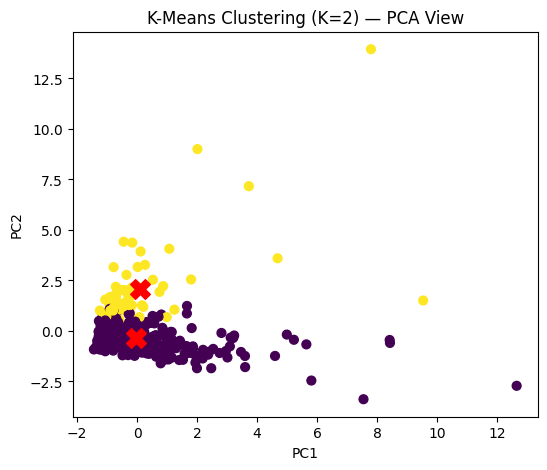

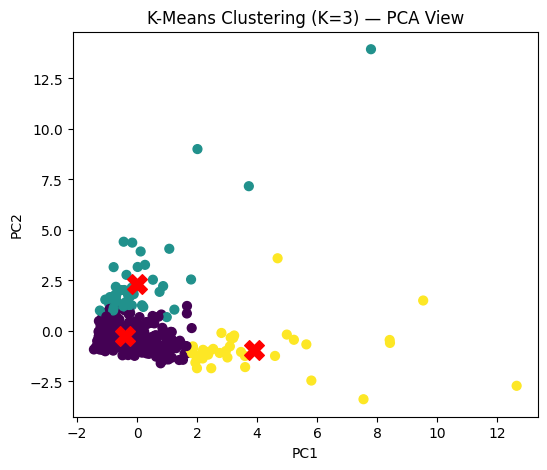

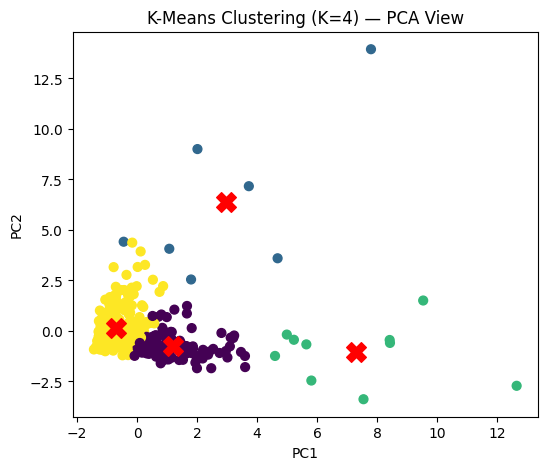

In [26]:
# Step 2: Apply K-Means clustering with proper visualization

k_values = [2, 3, 4]   # Define different values of K to test

# Loop through each value of K
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)   # Create KMeans model with k clusters
    labels = kmeans.fit_predict(X_scaled)            # Fit the model and get cluster labels for each point

    # Plot clusters using PCA (2D visualization)
    plt.figure(figsize=(6, 5))
    plt.scatter(X_pca2[:, 0], X_pca2[:, 1],
                c=labels, cmap='viridis', s=40)      # Color points based on cluster assignment

    # Transform cluster centers into PCA space for visualization
    centers_pca = PCA(n_components=2).fit(X_scaled).transform(kmeans.cluster_centers_)

    # Plot cluster centers
    plt.scatter(centers_pca[:, 0], centers_pca[:, 1],
                c='red', marker='X', s=200)          # Red X marks the cluster centers

    # Add labels and title
    plt.title(f"K-Means Clustering (K={k}) — PCA View")
    plt.xlabel("PC1")                                # First principal component
    plt.ylabel("PC2")                                # Second principal component
    plt.show()

# 

In [27]:
# K-Means groups similar data points together based on distance.
# Different values of K produce different cluster structures.
# Cluster centers represent the average point of each cluster.
# ===== K-Means Clustering  =====

# For K = 2:
# The data is divided into two main clusters.
# One cluster represents higher-value customers,
# while the other contains the majority of customers.
# However, there is some overlap between clusters,
# indicating that K = 2 may not fully capture the data structure.

# For K = 3:
# Clustering improves significantly with three clusters.
# A new cluster appears representing high-spending customers or outliers.
# The separation between clusters becomes clearer,
# suggesting that K = 3 better represents the dataset.

# For K = 4:
# The data is divided into more clusters, but some clusters become very small.
# This indicates over-segmentation, where natural groups are split unnecessarily.
# The clustering quality does not improve compared to K = 3.

# Final Conclusion:
# Based on visual analysis, K = 3 appears to be the optimal number of clusters.
# It provides a good balance between separation and compactness,
# without overfitting the data.

In [ ]:
# Import evaluation metrics for clustering performance

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score  
# Silhouette Score: measures how well each point fits within its cluster (higher is better)
# Davies-Bouldin Index: measures similarity between clusters (lower is better)
# Calinski-Harabasz Score: evaluates cluster separation (higher is better)

import pandas as pd  
# Used to create and manage data tables (DataFrames) for storing results

import numpy as np  
# Used for numerical operations and handling arrays

from scipy.spatial.distance import pdist, squareform  
# Used to compute distances between data points (needed for Dunn Index calculation)

from sklearn.metrics import adjusted_rand_score
# Used to compare clustering results with ground-truth labels (higher is better)(1->perfect match, 0->random, 0< ->worse than random)
#works for all clustering algorithms , interita olny with kmeans

In [72]:
# Dunn Index function
# This metric evaluates clustering quality based on:
# - separation between clusters (inter-cluster distance)
# - compactness within clusters (intra-cluster distance)
# Higher Dunn Index = better clustering

def dunn_index(X, labels):
    
    distances = squareform(pdist(X))  
    # Compute pairwise distance matrix between all data points

    unique_labels = np.unique(labels)  
    # Get all unique cluster labels

    min_inter = np.inf  
    # Initialize minimum inter-cluster distance (start with very large value)

    max_intra = 0  
    # Initialize maximum intra-cluster distance

    # Loop over each cluster
    for i in unique_labels:
        cluster_i = X[labels == i]  
        # Select all points belonging to cluster i

        if len(cluster_i) < 2:
            continue  
        # Skip clusters with less than 2 points

        intra = np.max(pdist(cluster_i))  
        # Compute maximum distance within the cluster (intra-cluster distance)

        max_intra = max(max_intra, intra)  
        # Keep track of the largest intra-cluster distance

        # Compare cluster i with all other clusters
        for j in unique_labels:
            if i != j:
                cluster_j = X[labels == j]  
                # Select points from another cluster

                inter = np.min(np.linalg.norm(cluster_i[:, None] - cluster_j, axis=2))  
                # Compute minimum distance between clusters i and j (inter-cluster distance)

                min_inter = min(min_inter, inter)  
                # Keep track of the smallest inter-cluster distance

    return min_inter / max_intra  
    # Dunn Index = (minimum inter-cluster distance) / (maximum intra-cluster distance)

In [85]:
# Create an empty list to store evaluation results
resultsKmeans = []

# Define different values of K to test
k_values = [2, 3, 4]

# Loop through each value of K
for k in k_values:

    # ===== K-MEANS CLUSTERING =====
    kmeans = KMeans(n_clusters=k, random_state=42)  
    # Create KMeans model with k clusters

    labels_km = kmeans.fit_predict(X_scaled)  
    # Fit the model and get cluster labels for each data point

    # Store evaluation results for this value of K
    resultsKmeans.append({
        "Algorithm": "KMeans",   # Name of clustering algorithm
        "K": k,                 # Number of clusters

        "Silhouette": silhouette_score(X_scaled, labels_km),  
        # Measures how well points fit within their cluster (higher is better)

        "DBI": davies_bouldin_score(X_scaled, labels_km),  
        # Measures similarity between clusters (lower is better)

        "CH": calinski_harabasz_score(X_scaled, labels_km),  
        # Measures cluster separation (higher is better)

        "Dunn": dunn_index(X_scaled, labels_km) , 
        # Ratio of inter-cluster distance to intra-cluster distance (higher is better)

         "Inertia": kmeans.inertia_  , # ✅ extra metric
# Inertia: measures how compact the clusters are (lower is better)
# It is the same metric used in the Elbow Method

 
"ARI": adjusted_rand_score(y['Channel'], labels_km),

    })

In [86]:
# Convert results into a DataFrame for easy visualization
results_dfKmeans = pd.DataFrame(resultsKmeans)

# Display results
results_dfKmeans

,Algorithm,K,Silhouette,DBI,CH,Dunn,Inertia,ARI
0,KMeans,2,0.399828,1.582613,72.076232,0.012087,2266.955267,-0.047378
1,KMeans,3,0.458263,1.249095,132.363139,0.017884,1644.059851,0.108674
2,KMeans,4,0.349391,1.147502,143.870966,0.022274,1326.674608,0.512418


In [32]:
# Evaluation Metrics Interpretation:
# Silhouette Score: higher is better
# DBI: lower is better
# Calinski-Harabasz: higher is better
# Dunn Index: higher is better
# Inertia: lower is better


Spectral Clustering

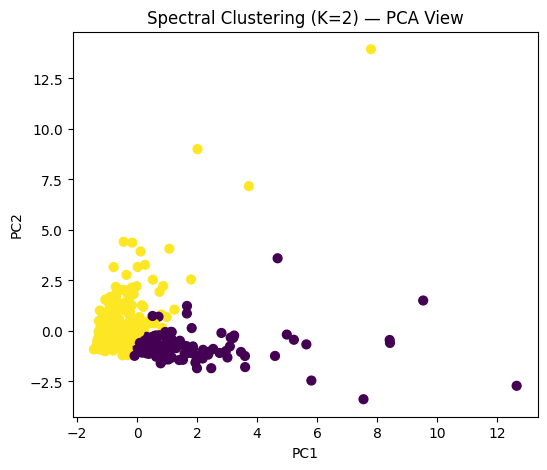

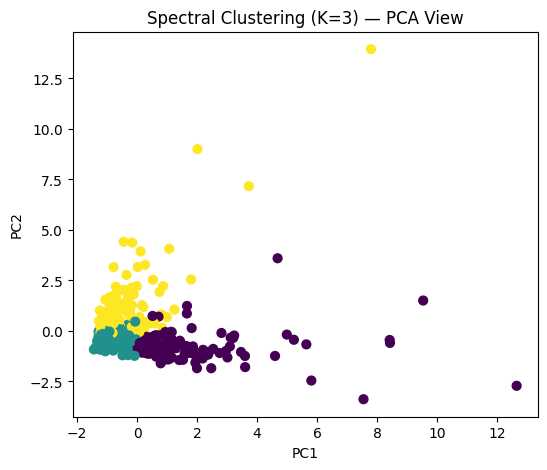

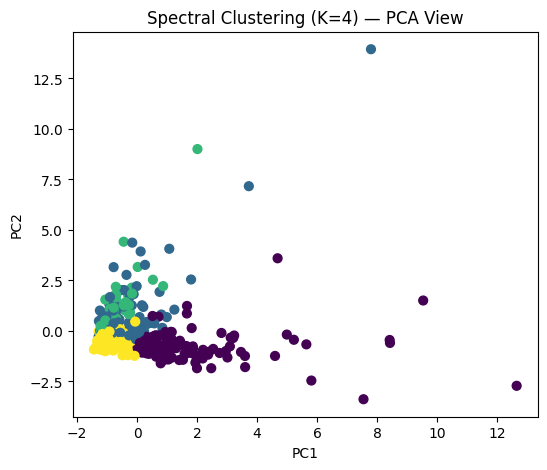

In [ ]:
from sklearn.cluster import SpectralClustering

#plot the spectral clustering using PCA
for k in k_values:
    spectral = SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors',  # IMPORTANT
        random_state=42
    )

    labels = spectral.fit_predict(X_scaled)

    # Plot using PCA 
    plt.figure(figsize=(6, 5))
    plt.scatter(
        X_pca2[:, 0],
        X_pca2[:, 1],
        c=labels,
        cmap='viridis',
        s=40
    )

    plt.title(f"Spectral Clustering (K={k}) — PCA View")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

Evaluating the spectral clustering for each k , using (Dunn Index, DBI, Calinski–Harabasz Index)

In [ ]:
resultsSC = []

for k in k_values:

    spectral = SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors',
        random_state=42
    )

    labels_sc = spectral.fit_predict(X_scaled)

    resultsSC.append({
        "Algorithm": "Spectral",
        "K": k,

        "Silhouette": silhouette_score(X_scaled, labels_sc),
        "DBI": davies_bouldin_score(X_scaled, labels_sc),
        "CH": calinski_harabasz_score(X_scaled, labels_sc),
        "Dunn": dunn_index(X_scaled, labels_sc),
        "Inertia": np.nan,
"ARI": adjusted_rand_score(y['Channel'], labels_sc),
        
    })

    
    
    
    


In [ ]:
results_dfSC = pd.DataFrame(resultsSC)
results_dfSC

,Algorithm,K,Silhouette,DBI,CH,Dunn,ARI
0,Spectral,2,0.347806,1.261365,122.398552,0.021921,0.543590
1,Spectral,3,0.207650,1.348957,98.475227,0.011226,0.285763
2,Spectral,4,0.209502,1.368813,78.581327,0.008597,0.227233


Gaussian Mixture Model

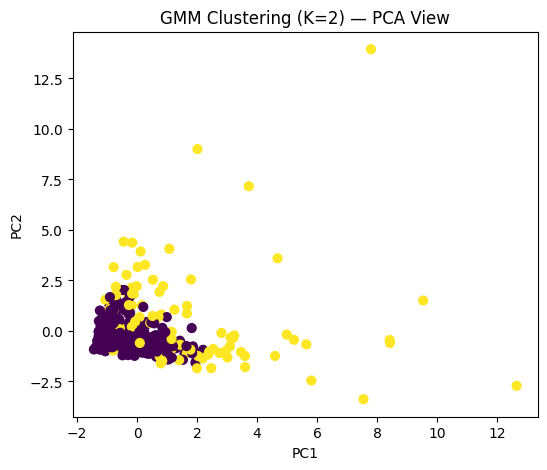

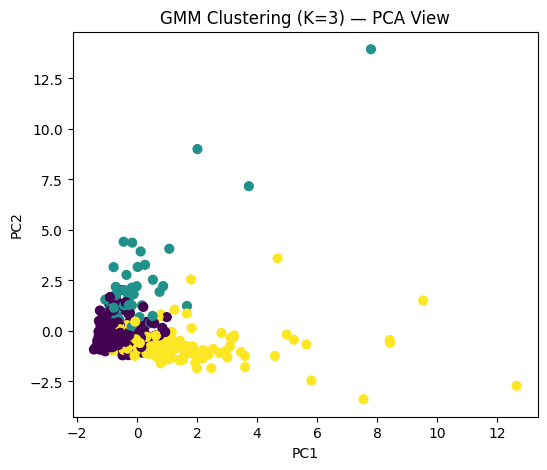

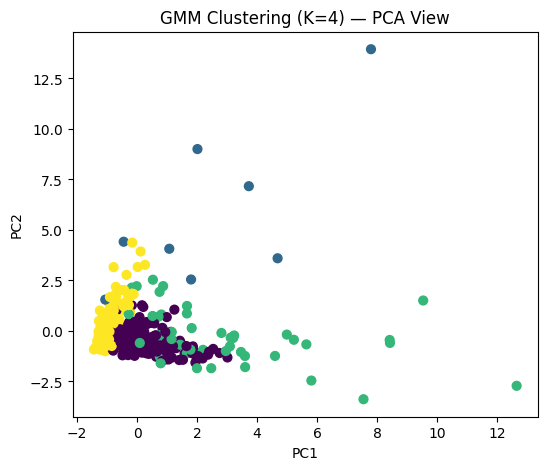

In [78]:
from sklearn.mixture import GaussianMixture
for k in k_values:
    gmm = GaussianMixture(n_components=k, random_state=42)
    
    gmm.fit(X_scaled)
    labels_gmm = gmm.predict(X_scaled)

    plt.figure(figsize=(6, 5))
    plt.scatter(
        X_pca2[:, 0],
        X_pca2[:, 1],
        c=labels_gmm,
        cmap='viridis',
        s=40
    )

    plt.title(f"GMM Clustering (K={k}) — PCA View")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

In [ ]:
resultsGMM = []
for k in k_values:

    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    labels_gmm = gmm.predict(X_scaled)

    resultsGMM.append({
        "Algorithm": "GMM",
        "K": k,

        "Silhouette": silhouette_score(X_scaled, labels_gmm),
        "DBI": davies_bouldin_score(X_scaled, labels_gmm),
        "CH": calinski_harabasz_score(X_scaled, labels_gmm),
        "Dunn": dunn_index(X_scaled, labels_gmm),
"Inertia": np.nan,  # GMM does not have inertia
        "ARI": adjusted_rand_score(y['Channel'], labels_gmm),

        
    })

    
    

In [ ]:
results_dfGMM = pd.DataFrame(resultsGMM)
results_dfGMM

,Algorithm,K,Silhouette,DBI,CH,Dunn,ARI,Inertia
0,GMM,2,0.449708,1.907724,84.414893,0.018758,0.095617,NaN
1,GMM,3,0.315904,1.471152,91.252433,0.015668,0.285498,NaN
2,GMM,4,0.163255,1.705931,74.030195,0.011552,0.299701,NaN


Comparing all cluster results 

In [87]:
final_results = resultsKmeans + resultsSC + resultsGMM
final_df = pd.DataFrame(final_results)

In [88]:
#display 
final_df


,Algorithm,K,Silhouette,DBI,CH,Dunn,Inertia,ARI
0,KMeans,2,0.399828,1.582613,72.076232,0.012087,2266.955267,-0.047378
1,KMeans,3,0.458263,1.249095,132.363139,0.017884,1644.059851,0.108674
2,KMeans,4,0.349391,1.147502,143.870966,0.022274,1326.674608,0.512418
3,Spectral,2,0.347806,1.261365,122.398552,0.021921,NaN,0.543590
4,Spectral,3,0.207650,1.348957,98.475227,0.011226,NaN,0.285763
5,Spectral,4,0.209502,1.368813,78.581327,0.008597,NaN,0.227233
6,GMM,2,0.449708,1.907724,84.414893,0.018758,NaN,0.095617
7,GMM,3,0.315904,1.471152,91.252433,0.015668,NaN,0.285498
8,GMM,4,0.163255,1.705931,74.030195,0.011552,NaN,0.299701


# Results analysis:

0️- Elbow Method Analysis

The Elbow Method was used to determine the optimal number of clusters for KMeans. Inertia, which measures the compactness of clusters (lower is better), was computed for K = 1–9.

From the plot (plotted in the elbow method cell):

Inertia decreases sharply from K = 1 to K = 3, meaning adding clusters significantly improves cluster compactness.
After K = 3, inertia decreases more gradually, showing diminishing returns from adding more clusters.

Interpretation:

The “elbow” occurs around K = 3, suggesting this is the optimal number of clusters.
This K value balances model simplicity with cluster quality, and it was used as a reference for KMeans evaluation.





1️- Comparison between the clustering algorithms:

The clustering performance was evaluated for KMeans, Spectral Clustering, and Gaussian Mixture Models (GMM) using internal validation metrics (Silhouette, Davies–Bouldin Index (DBI), Calinski–Harabasz (CH), Dunn Index) and Adjusted Rand Index (ARI) against the ground-truth labels.

Observations:

KMeans:

Generally achieves the highest Calinski–Harabasz Index for K = 3 and 4, indicating well-separated clusters.
Silhouette is highest at K = 3, suggesting good cluster compactness.
ARI improves significantly at K = 4, indicating better alignment with the ground-truth labels.


Spectral Clustering:

Performs best in terms of ARI at K = 2, showing the clusters match the true labels closely when using fewer clusters.
Silhouette and CH scores decrease as K increases, indicating the clusters are less compact and well-separated at higher K.


Gaussian Mixture Model (GMM):

Achieves the highest Silhouette score at K = 2, suggesting compact clusters in this configuration.
ARI remains relatively low across all K, meaning the GMM clusters do not align strongly with the ground-truth labels.
Performance decreases as K increases, with lower Silhouette and Dunn Index values.

Conclusion:

 KMeans is the most consistent algorithm across different K values, balancing cluster compactness (Silhouette) and separation (CH) while improving ARI at higher K.

 Spectral Clustering is effective for smaller K (K = 2), achieving the highest ARI, but its cluster quality decreases with more clusters.

 GMM performs well for very compact clusters at K = 2 but does not align well with the true labels as K increases.





2-Analysis of the impact of the number of clusters K 

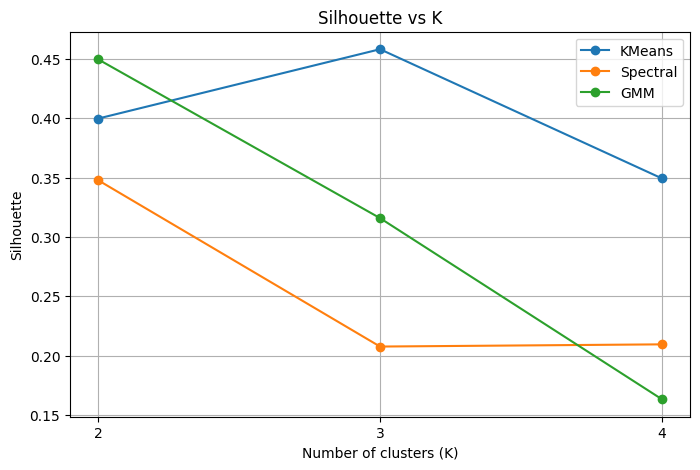

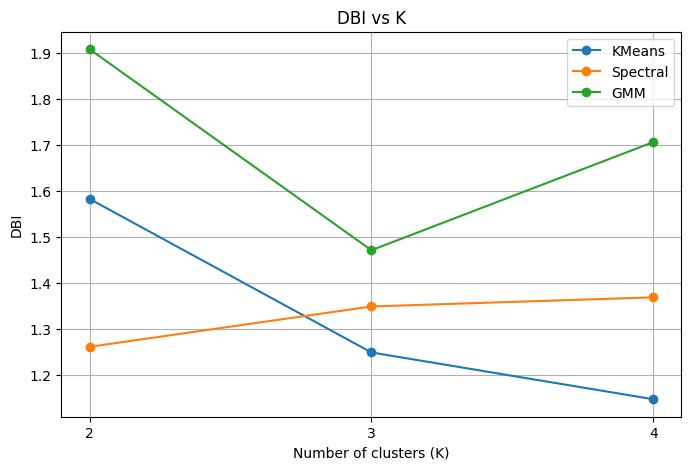

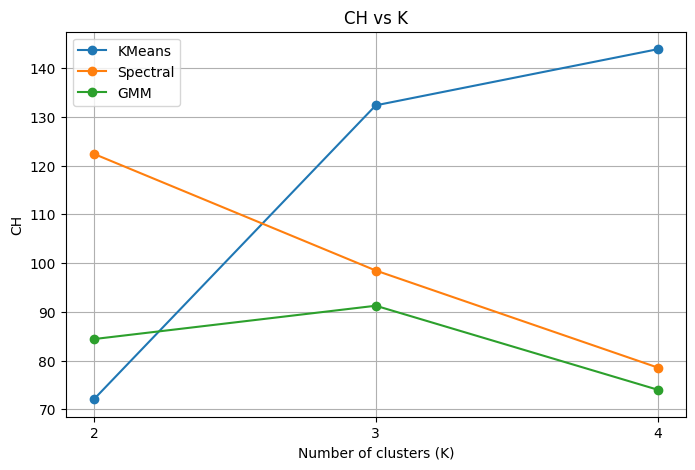

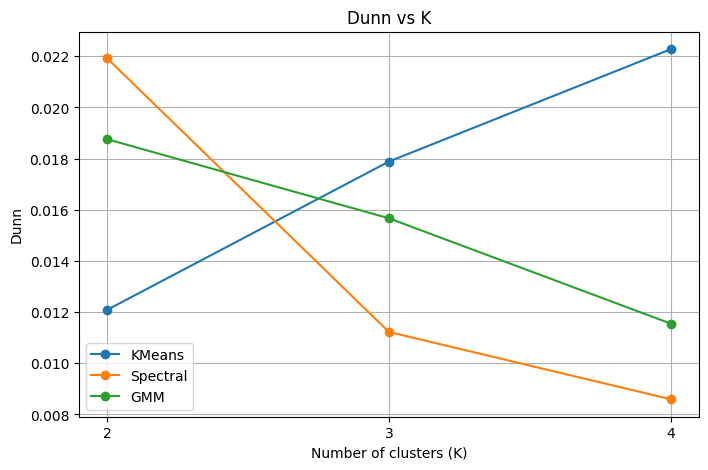

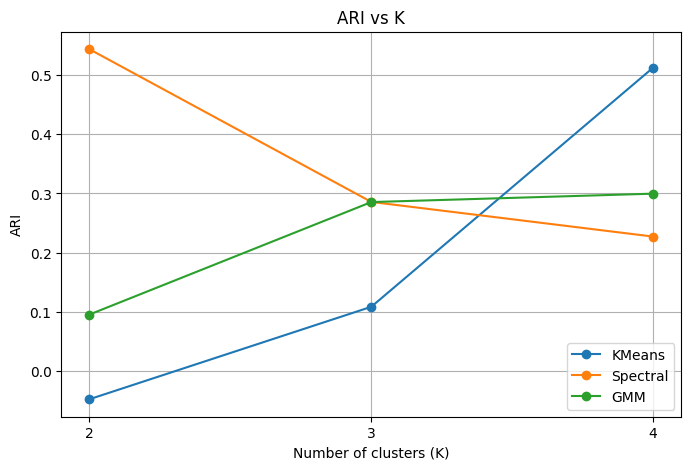

In [93]:
import pandas as pd
import matplotlib.pyplot as plt



metrics = ["Silhouette", "DBI", "CH", "Dunn", "ARI"]
algorithms = final_df['Algorithm'].unique()

# Plot metrics vs K for each algorithm
for metric in metrics:
    plt.figure(figsize=(8,5))
    for algo in algorithms:
        subset = final_df[final_df['Algorithm'] == algo]
        plt.plot(subset['K'], subset[metric], marker='o', label=algo)
    plt.title(f"{metric} vs K")
    plt.xlabel("Number of clusters (K)")
    plt.ylabel(metric)
    plt.xticks(subset['K'].unique())
    plt.legend()
    plt.grid(True)
    plt.show()

# # Optional: textual summary of K impact
# summary = []
# for algo in algorithms:
#     subset = final_df[final_df['Algorithm'] == algo]
#     best_K = subset.loc[subset['Silhouette'].idxmax(), 'K']
#     summary.append(f"{algo}: Silhouette is highest at K={best_K}, indicating best cluster compactness at this K.")
    
# summary_text = "\n".join(summary)
# print("summary of the impact of K:\n")
# print(summary_text)

Summary of the Impact of K:
 
 KMeans → best cluster compactness and separation at K = 3 (matches Elbow Method suggestion).

 Spectral Clustering → highest ARI at K = 2.

 GMM → compact clusters at K = 2, alignment with labels remains low.

Elbow Method Takeaway:
K = 3 was chosen as a good balance, and this informed the KMeans evaluation.(plotted above)

Visualization of clustering results:

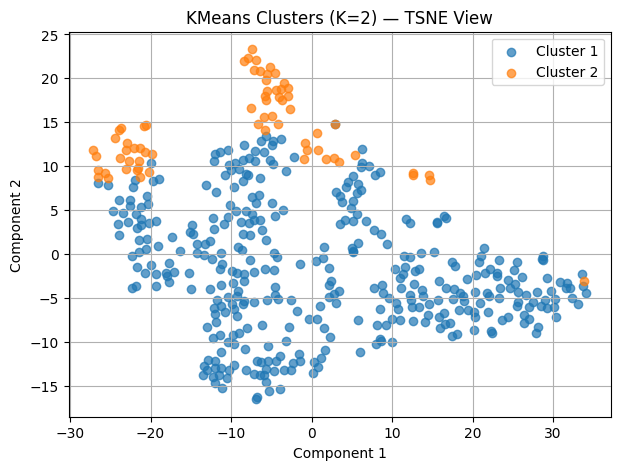

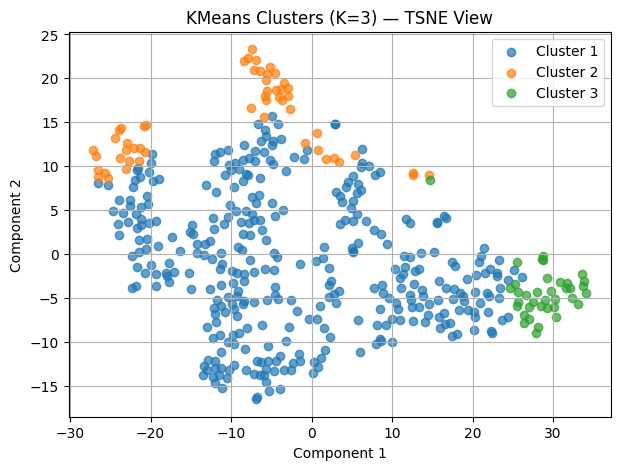

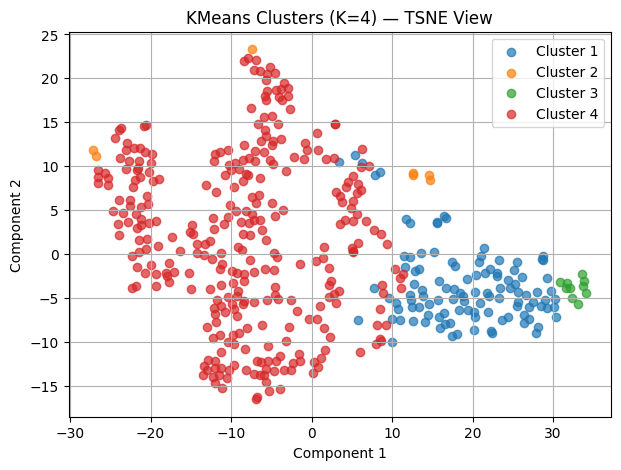

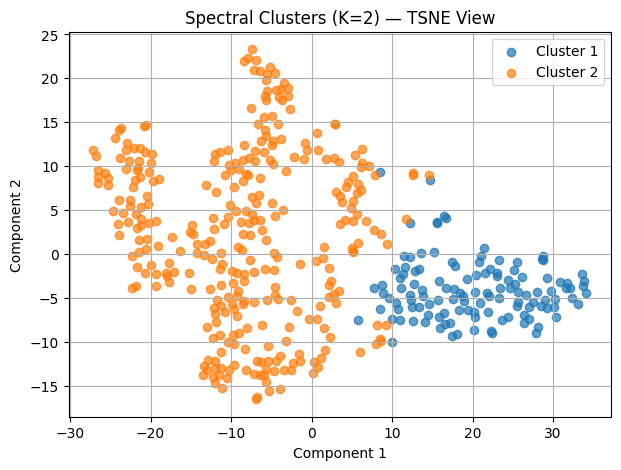

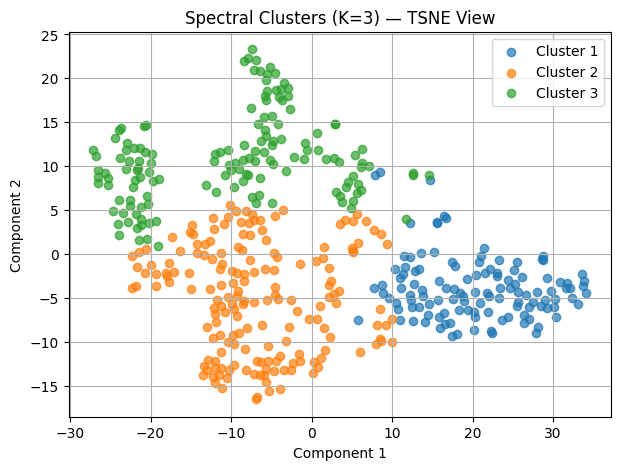

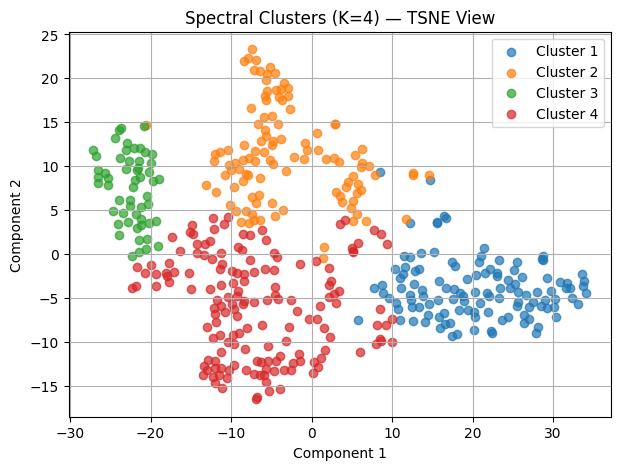

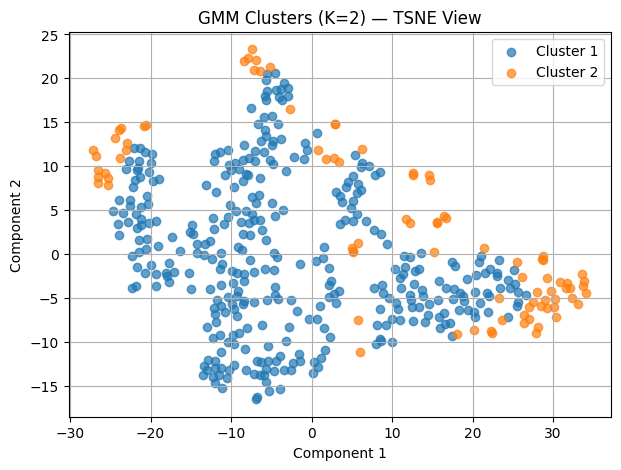

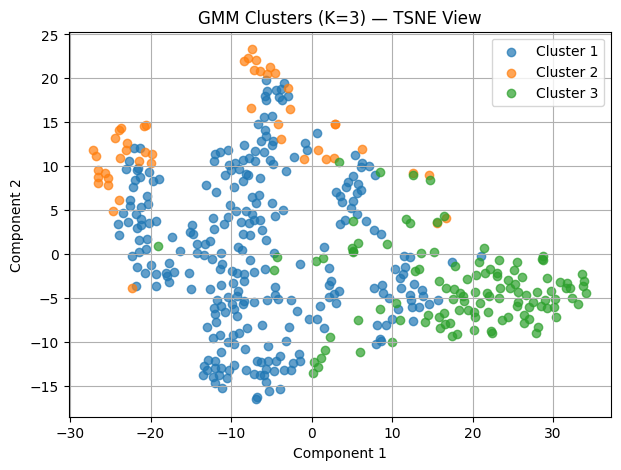

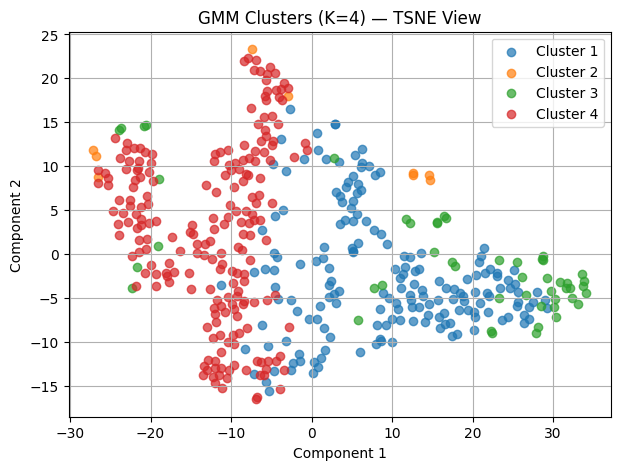

In [ ]:
# Collect all cluster labels for all k values as teh existing labels save the last k (4), in dictionaries for plotting
labels_kmeans_dict = {}
labels_spectral_dict = {}
labels_gmm_dict = {}

k_values = [2, 3, 4]

# KMeans labels
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels_kmeans_dict[k] = kmeans.fit_predict(X_scaled)

# Spectral Clustering labels
for k in k_values:
    spectral = SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors',
        random_state=42
    )
    labels_spectral_dict[k] = spectral.fit_predict(X_scaled)

# Gaussian Mixture Model labels
for k in k_values:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    labels_gmm_dict[k] = gmm.predict(X_scaled)

# Choose dimensionality reduction method: PCA or t-SNE (PCA already done above)
reducer =  "TSNE"  # or "PCA" 

# Prepare 2D data for plotting
if reducer == "PCA":
    X_2d = X_pca2  # You already have 2D PCA from earlier
else:
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, learning_rate='auto', init='pca', max_iter=1000)
    X_2d = tsne.fit_transform(X_scaled)

# Dictionary of all clustering results
cluster_algorithms = {
    "KMeans": labels_kmeans_dict,
    "Spectral": labels_spectral_dict,
    "GMM": labels_gmm_dict
}

# Plot all clusters
for algo, labels_dict in cluster_algorithms.items():
    for K, labels in labels_dict.items():
        plt.figure(figsize=(7,5))
        for cluster in np.unique(labels):
            plt.scatter(
                X_2d[labels == cluster, 0],
                X_2d[labels == cluster, 1],
                label=f"Cluster {cluster+1}",
                alpha=0.7
            )
        plt.title(f"{algo} Clusters (K={K}) — {reducer} View")
        plt.xlabel("Component 1")
        plt.ylabel("Component 2")
        plt.legend()
        plt.grid(True)
        plt.show()

4-Interpretation of evaluation metric values (what high/low values mean):



1. Silhouette Score (−1 to 1, higher is better)

    Measures how well each point fits within its assigned cluster compared to other clusters.

    High (~1): well-separated, compact clusters

    Near 0: overlapping clusters

    Negative: incorrect cluster assignments

    Observation:

       K-Means performs best at K = 3

      Spectral decreases with higher K

      GMM performs best at K = 2




2. Davies–Bouldin Index (DBI) (lower is better)

    Measures similarity between clusters.

    Low: clusters are well-separated

    High: clusters overlap

    Observation:

      K-Means has lowest DBI at K = 3

      Spectral and GMM worsen as K increases
 



3. Calinski–Harabasz Index (CH) (higher is better)

    Measures ratio of between-cluster variance to within-cluster variance.

    High: strong separation and compactness

    Low: weak cluster structure

    Observation:

      K-Means peaks at K = 3 and 4

      Spectral and GMM decline with higher K





4. Dunn Index (higher is better)

    Measures cluster separation relative to cluster spread.

    High: well-separated and tight clusters

    Low: overlapping or dispersed clusters

    Observation:

      K-Means maintains moderate stability

      Spectral and GMM decrease with higher K


5. Inertia (K-Means only, lower is better)

    Measures compactness of clusters (used in the Elbow Method).

    Decreases as K increases (expected behavior)

    The elbow point at K = 3 indicates optimal clustering



6. Adjusted Rand Index (ARI) (−1 to 1, higher is better)

    Measures similarity between predicted clusters and true labels.

     1: perfect match
     0: random clustering
     <0: worse than random

    Observation:

      Spectral performs best at K = 2

      K-Means improves at K = 4
      
      GMM shows weak alignment with true labels

# Cluster Profiling:

profile each algorithm at its best K (KMeans	3, Spectral	2, GMM	2)

Cluster profiling is performed to understand the characteristics of each cluster by analyzing the average feature values within each group.

In [95]:
#get the best k for each algo using teh previously defined dictionaries 
labels_km = labels_kmeans_dict[3]
labels_sc = labels_spectral_dict[2]
labels_gmm = labels_gmm_dict[2]

In [96]:
#the actual profiling 


# Function to compute and display cluster profiles
def cluster_profile(X_original, labels, name):
    
    # Make a copy of the original dataset (NOT scaled) , to easlily iterpret the results 
    df_profile = X_original.copy()
    
    # Add the cluster labels as a new column
    df_profile['Cluster'] = labels
    
    # Group the data by cluster
    # Then compute the mean of each feature inside each cluster
    # round(2) is used to make the numbers easier to read
    profile = df_profile.groupby('Cluster').mean().round(2)
    
    # Count how many data points are in each cluster to understand the size of each cluster
    profile['Size'] = df_profile['Cluster'].value_counts().sort_index()
    
    print(f"\n{name} Cluster Profile:\n")
    print(profile)
    
    return profile


# Apply the function to each clustering algorithm using the best K(labels set above)

# KMeans with K = 3 (best based on multiple evaluation metrics)
profile_km = cluster_profile(X, labels_km, "KMeans (K=3)")

# Spectral Clustering with K = 2 (best ARI)
profile_sc = cluster_profile(X, labels_sc, "Spectral (K=2)")

# Gaussian Mixture Model with K = 2 (best silhouette for GMM)
profile_gmm = cluster_profile(X, labels_gmm, "GMM (K=2)")


KMeans (K=3) Cluster Profile:

            Fresh      Milk   Grocery   Frozen  Detergents_Paper  Delicassen  \
Cluster                                                                        
0         8935.50   4228.53   5848.03  2167.23           1913.61     1102.12   
1        34540.11   5860.36   6122.62  9841.74            981.47     3664.25   
2         8704.86  20534.41  30466.24  1932.62          14758.84     2459.35   

         Size  
Cluster        
0         350  
1          53  
2          37  

Spectral (K=2) Cluster Profile:

            Fresh      Milk   Grocery   Frozen  Detergents_Paper  Delicassen  \
Cluster                                                                        
0         5920.05  12211.59  18058.59  1677.13           8104.67     1769.45   
1        14332.97   3335.04   4073.63  3607.04            877.63     1431.04   

         Size  
Cluster        
0         122  
1         318  

GMM (K=2) Cluster Profile:

            Fresh      Milk   Grocery  

Cluster Label Interpretation

The cluster labels (0, 1, 2) do not carry inherent meaning and are assigned arbitrarily by the clustering algorithms. Therefore, interpretation was performed by analyzing the average feature values within each cluster.


For K-Means (K = 3), the clusters represent:

Cluster 0 represents the majority of customers with moderate spending across all product categories.

Cluster 1 corresponds to Horeca-type customers, characterized by high spending on Fresh and Frozen products.

Cluster 2 represents Retail customers, with significantly higher spending on Grocery, Milk, and Detergents.



For Spectral Clustering the data is clearly divided into two main groups corresponding to:
 0-Horeca and 1-Retail customers.




For GMM, the clustering reflects customer purchasing volume:
 separating 0-low-spending customers from 1-high-value customers.